In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

In [2]:
df = pd.read_csv("../data/processed/tcs_stock_data_cleaned.csv")

df["Date"] = pd.to_datetime(df["Date"])
df = df.set_index("Date")

data = df[["Close"]]
data.head()

,Close
Date,
2018-01-01,1322.800049
2018-01-02,1315.599976
2018-01-03,1319.324951
2018-01-04,1328.550049
2018-01-05,1344.599976


In [3]:
split_index = int(len(data) * 0.8)

train_data = data.iloc[:split_index]
test_data = data.iloc[split_index:]

print("Train shape:", train_data.shape)
print("Test shape:", test_data.shape)

Train shape: (1580, 1)
Test shape: (395, 1)


In [4]:
scaler = MinMaxScaler(feature_range=(0, 1))

train_scaled = scaler.fit_transform(train_data)
test_scaled = scaler.transform(test_data)

In [5]:
def create_sequences(dataset, time_steps=60):
    X, y = [], []

    for i in range(time_steps, len(dataset)):
        X.append(dataset[i-time_steps:i, 0])
        y.append(dataset[i, 0])

    return np.array(X), np.array(y)

In [6]:
time_steps = 60

X_train, y_train = create_sequences(train_scaled, time_steps)

In [7]:
test_combined = np.concatenate((train_scaled[-time_steps:], test_scaled), axis=0)
X_test, y_test = create_sequences(test_combined, time_steps)

#### [samples, time_steps, features]

In [9]:
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (1520, 60, 1)
X_test shape: (395, 60, 1)


In [11]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input

model = Sequential()

model.add(Input(shape=(X_train.shape[1], 1)))

model.add(LSTM(units=50, return_sequences=True))
model.add(Dropout(0.2))

model.add(LSTM(units=50, return_sequences=False))
model.add(Dropout(0.2))

model.add(Dense(units=25))
model.add(Dense(units=1))

In [12]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 60, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 25)             │         1,275 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            26 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,901 (124.61 KB)

 Trainable params: 31,901 (124.61 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
model.compile(optimizer="adam", loss="mean_squared_error")

In [14]:
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

Epoch 1/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 5s 47ms/step - loss: 0.0314 - val_loss: 0.0130
Epoch 2/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - loss: 0.0045 - val_loss: 0.0013
Epoch 3/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - loss: 0.0035 - val_loss: 0.0012
Epoch 4/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - loss: 0.0032 - val_loss: 0.0024
Epoch 5/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - loss: 0.0028 - val_loss: 0.0014
Epoch 6/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - loss: 0.0027 - val_loss: 0.0012
Epoch 7/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - loss: 0.0025 - val_loss: 0.0013
Epoch 8/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step - loss: 0.0024 - val_loss: 0.0015
Epoch 9/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - loss: 0.0020 - val_loss: 0.0011
Epoch 10/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - loss: 0.0021 - val_loss: 0.0013
Epoch 11/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - loss: 0.0019 - val_loss: 0.0012
Epoch 12/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - loss: 0.0

In [15]:
predictions = model.predict(X_test)

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step


In [16]:
predictions = scaler.inverse_transform(predictions.reshape(-1, 1))
y_test_actual = scaler.inverse_transform(y_test.reshape(-1, 1))

In [17]:
predictions = predictions.flatten()
y_test_actual = y_test_actual.flatten()

In [18]:
mae = mean_absolute_error(y_test_actual, predictions)
print("MAE:", mae)

MAE: 72.89016762262658


In [19]:
rmse = np.sqrt(mean_squared_error(y_test_actual, predictions))
print("RMSE:", rmse)

RMSE: 96.04996588957466


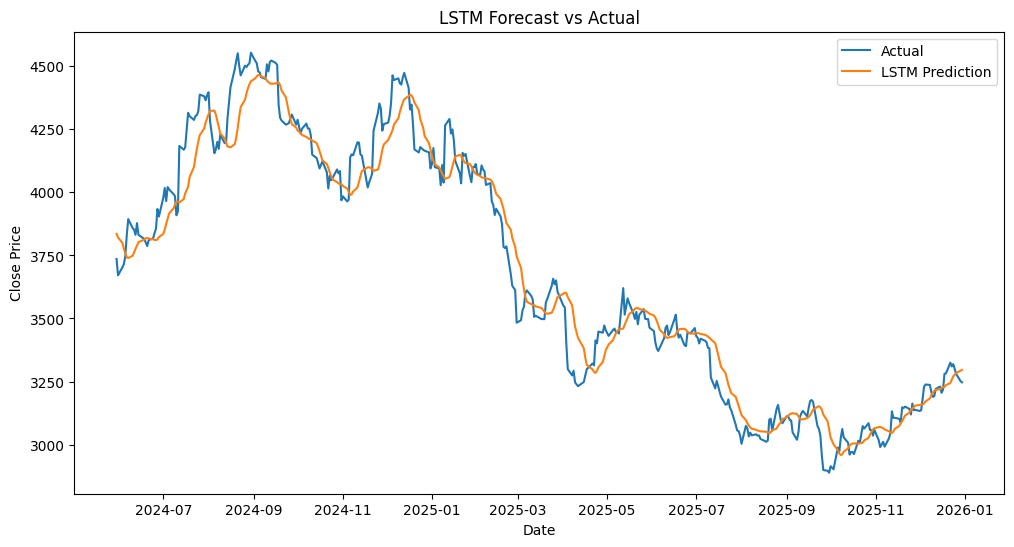

In [20]:
plt.figure(figsize=(12, 6))

plt.plot(test_data.index, data.iloc[split_index:]["Close"].values, label="Actual")
plt.plot(test_data.index, predictions, label="LSTM Prediction")

plt.title("LSTM Forecast vs Actual")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.legend()
plt.show()

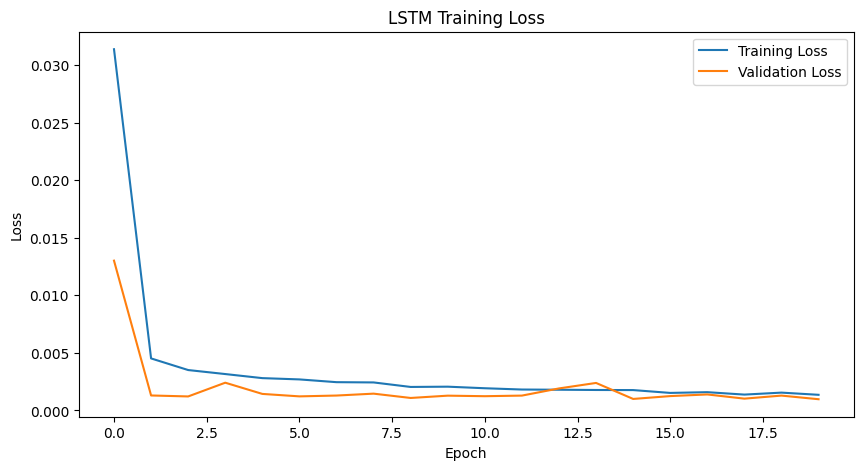

In [21]:
plt.figure(figsize=(10, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("LSTM Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [22]:
results = pd.DataFrame({
    "Date": test_data.index,
    "Actual": y_test_actual,
    "LSTM_Prediction": predictions
})

results.to_csv("../data/processed/lstm_predictions.csv", index=False)

In [23]:
model.save("../models/lstm_model.h5")